In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load the dataset**

In [ ]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

**Data Cleaning and Preprocessing**

**1. Drop Irrelevant Column**

In [ ]:
df.drop("customerID", axis=1, inplace=True) #customerID is just an identifier, it has no predictive value

print("customerID column removed")

customerID column removed


**2. Fix TotalCharges Issue**

In [ ]:
if df["TotalCharges"].dtype == "object":
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("TotalCharges converted to numeric")

TotalCharges converted to numeric


**3. Check Missing Values**

In [ ]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
# We will fill missing TotalCharges with median (safe for skewed data)

df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

print("Missing values handled")

Missing values handled


/tmp/ipykernel_687/3929943163.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


**4. Convert Target Variable (Churn)**

In [ ]:
# Yes -> 1, No -> 0

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
print("Target variable encoded")

Target variable encoded


**5. Encode Categorical Columns**

In [ ]:
# We convert all object (text) columns into numeric using one-hot encoding

df_encoded = pd.get_dummies(df, drop_first=True)
print("Categorical variables encoded")

Categorical variables encoded


**Final Check**

In [ ]:
print("\nFinal dataset shape:")
print(df_encoded.shape)

print("\nSample data:")
display(df_encoded.head())

print("\nData types after processing:")
print(df_encoded.dtypes)


Final dataset shape:
(7043, 31)

Sample data:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False



Data types after processing:
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service        

**Model Building**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Splitting Features & Target
, Train-Test Split**

In [ ]:
X = df_encoded.drop("Churn", axis=1) # X = all input features
y = df_encoded["Churn"] # y = target variable (Churn)

print("Features and target separated")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#stratify ensures that the same proportion of churners (Yes/No) are in both train and test sets

print("Train-test split completed")
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Features and target separated
Train-test split completed
Training data shape: (5634, 30)
Testing data shape: (1409, 30)


**Train Logistic Regression Model & Make predictions**

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model training completed")

y_pred = model.predict(X_test)
print("Predictions generated")

Model training completed
Predictions generated


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Model Evaluation**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)

print("\nConfusion Matrix:")
cm=confusion_matrix(y_test, y_pred)  #TN FP
                                     #FN TP
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Model Accuracy: 0.8034066713981547

Confusion Matrix:
[[924 111]
 [166 208]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



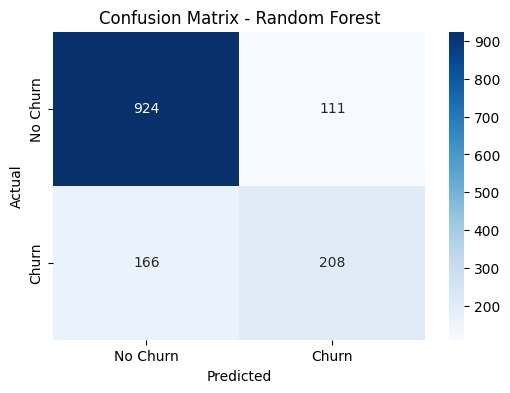

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["No Churn", "Churn"],yticklabels=["No Churn", "Churn"])
#annot=Show actual numbers inside each box
#fmt="d" -> Format numbers as integers where d is decimal integer format
#xticklabels=Labels for predicted values (X-axis)
#yticklabels=Labels for actual values (Y-axis)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Random Forest Model + Comparison**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#Train Random Forest Model

rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest model trained")

#Making Predictions

rf_pred = rf_model.predict(X_test)

#Evaluation

rf_accuracy = accuracy_score(y_test, rf_pred)

print("\nLogistic Regression Accuracy:", accuracy)
print("Random Forest Accuracy:", rf_accuracy)

if rf_accuracy > accuracy:
    print("\nRandom Forest performs better")
else:
    print("\nLogistic Regression performs better")

Random Forest model trained

Logistic Regression Accuracy: 0.8034066713981547
Random Forest Accuracy: 0.7863733144073811

Logistic Regression performs better


**Feature Importance Analysis**

In [ ]:
#Using Random Forest as it is best for importance

# Get feature importance from trained Random Forest model
importances = rf_model.feature_importances_

# Create a DataFrame for better understanding
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

#Sort by importance (descending order)
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print("Top 10 Important Features:")
display(feature_importance.head(10))  #display shows beautiful table format & preserves DataFrame structure

Top 10 Important Features:


,Feature,Importance
3,TotalCharges,0.192096
1,tenure,0.174733
2,MonthlyCharges,0.168413
28,PaymentMethod_Electronic check,0.038771
10,InternetService_Fiber optic,0.038641
25,Contract_Two year,0.030176
4,gender_Male,0.028321
13,OnlineSecurity_Yes,0.028191
26,PaperlessBilling_Yes,0.025617
5,Partner_Yes,0.023326


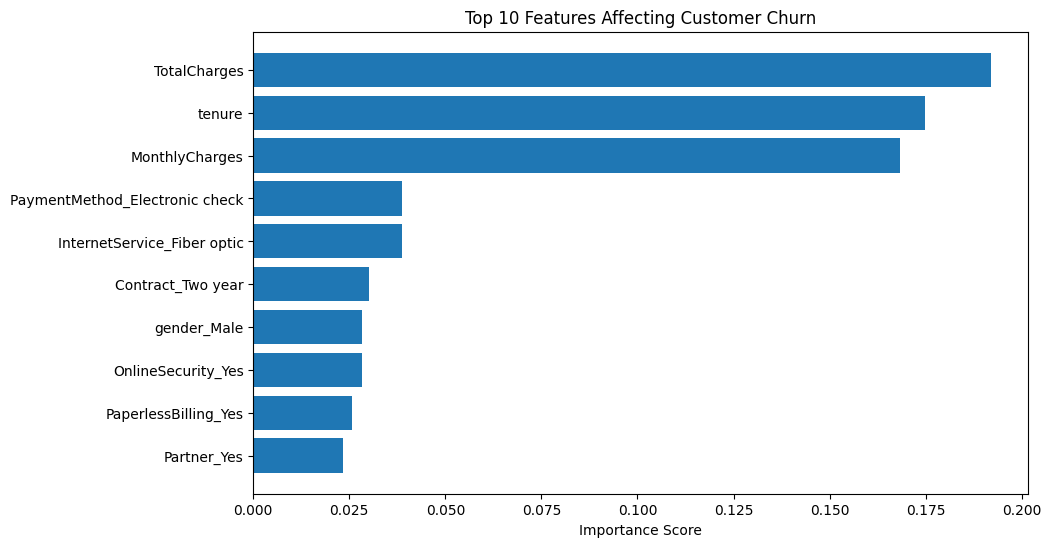

In [ ]:
#Visualization

top_features = feature_importance.head(10)  #Top 10 most important features affecting churn

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Importance"]) #barh=horizontal bar chart with y axis and then x axis
plt.gca().invert_yaxis() #get current axes, invert y axis
#By default: smallest importance appears on top
#We reverse it so: MOST important feature appears at TOP

plt.title("Top 10 Features Affecting Customer Churn")
plt.xlabel("Importance Score")

plt.show()

**Final Project Summary**

In [ ]:
print("CUSTOMER CHURN PREDICTION PROJECT COMPLETED\n")

print("Data Cleaning Done")
print("Feature Engineering Done (Encoding, Missing Values handled)")
print("Model 1: Logistic Regression trained")
print("Confusion Matrix visualized")
print("Model 2: Random Forest trained")
print("Model Comparison completed")
print("Feature Importance analyzed\n")

print("FINAL INSIGHT:")
print("Customer churn is mainly influenced by factors like contract type, tenure, and monthly charges.")


CUSTOMER CHURN PREDICTION PROJECT COMPLETED

Data Cleaning Done
Feature Engineering Done (Encoding, Missing Values handled)
Model 1: Logistic Regression trained
Confusion Matrix visualized
Model 2: Random Forest trained
Model Comparison completed
Feature Importance analyzed

FINAL INSIGHT:
Customer churn is mainly influenced by factors like contract type, tenure, and monthly charges.
